In [129]:
# Лабораторная работа: Комплексный анализ эффективности электромагнитных экранов
# (NumPy + Pandas + Matplotlib)

# Лабораторная работа: Комплексный анализ эффективности электромагнитных экранов

## Цели работы

1. **Закрепить навыки работы с NumPy**: создание массивов, векторизация, булевы маски, индексация
2. **Закрепить навыки работы с Pandas**: создание DataFrame с правильными ключами, фильтрация, сортировка, группировка
3. **Закрепить навыки работы с Matplotlib**: построение различных типов графиков (линейные, столбчатые), оформление
4. **Применить всё вместе** на реальной инженерной задаче — расчёт экранирующей способности (SE) многослойных экранов

---


---
## 1. Теоретический блок: Электромагнитное экранирование

### 1.1. Что такое эффективность экранирования (SE)?

**Эффективность экранирования** (Shielding Effectiveness, SE) — это мера способности
материала или конструкции ослаблять электромагнитное поле. Измеряется в децибелах (дБ):

$$SE = 20 \cdot \log_{10}\left(\frac{1}{|T|}\right) \text{, дБ}$$

где:
- $T$ — коэффициент прохождения электромагнитной волны через экран (комплексная величина)
- $|T|$ — модуль коэффициента прохождения

**Чем больше SE — тем лучше экран!**
- $SE = 0$ дБ → экран не работает (всё проходит)
- $SE = 20$ дБ → поле ослаблено в 10 раз
- $SE = 40$ дБ → поле ослаблено в 100 раз
- $SE = 60$ дБ → поле ослаблено в 1000 раз

### 1.2. Метод матриц передачи (Transfer Matrix Method)

Для многослойного экрана каждый слой описывается **матрицей передачи** $A$:

$$A_{\text{слой}} = \begin{pmatrix} \cosh(\gamma \cdot t) & z \cdot \sinh(\gamma \cdot t) \\ \frac{\sinh(\gamma \cdot t)}{z} & \cosh(\gamma \cdot t) \end{pmatrix}$$

Общая матрица всех слоёв:

$$A_{\text{total}} = A_1 \cdot A_2 \cdot \ldots \cdot A_n$$

Коэффициент прохождения:

$$T = \frac{2 Z_0}{A_{10} \cdot Z_0^2 + A_{11} \cdot Z_0 + A_{00} \cdot Z_0 + A_{01}}$$

где $Z_0 = 376.73$ Ом — импеданс свободного пространства.

### 1.3. Параметры материала слоя

Для **металла** (type = 1):

$$z = \sqrt{\frac{j \omega \mu_a}{\sigma + j \omega \varepsilon_a}}$$

$$\gamma = \sqrt{j \omega \mu_a \cdot (\sigma + j \omega \varepsilon_a)}$$

Для **композита** (type = 2):

$$\sigma_{\text{comp}} = \omega \varepsilon_0 \cdot \text{Im}(\varepsilon_r)$$

$$z = (1 + j) \sqrt{\frac{\omega \mu_a}{\sigma_{\text{comp}}}}$$

$$\gamma = j \sqrt{\omega \mu_a \cdot (\sigma_{\text{comp}} + j \omega \varepsilon_0 \cdot \text{Re}(\varepsilon_r))}$$

где:
- $\omega = 2\pi f$ — угловая частота, рад/с
- $\mu_a = \mu_r \cdot \mu_0$ — абсолютная магнитная проницаемость, Гн/м
- $\varepsilon_a = \varepsilon_r \cdot \varepsilon_0$ — абсолютная диэлектрическая проницаемость, Ф/м
- $\sigma$ — удельная электропроводность, См/м
- $t$ — толщина слоя, м
- $\mu_0 = 4\pi \times 10^{-7}$ Гн/м — магнитная постоянная
- $\varepsilon_0 = 8.854 \times 10^{-12}$ Ф/м — электрическая постоянная
- $Z_0 = 376.73$ Ом — импеданс свободного пространства

### 1.4. Формат входных данных (массив table)

Каждый слой экрана описывается строкой из 5 параметров:

| Столбец | Параметр | Обозначение | Единицы |
|---------|----------|-------------|---------|
| 0 | Относительная магнитная проницаемость | $\mu_r$ | безразм. |
| 1 | Относительная диэлектрическая проницаемость | $\varepsilon_r$ | безразм. |
| 2 | Удельная электропроводность | $\sigma$ | См/м |
| 3 | Толщина слоя | $t$ | м |
| 4 | Тип материала | type | 1=металл, 2=композит |

**Пример**: медный лист толщиной 0.5 мм:
```
[1.0, 1.0, 5.8e7, 0.5e-3, 1]
```

---
## 2. Импорт библиотек и физические константы

In [130]:
# === ИМПОРТ БИБЛИОТЕК ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Для воспроизводимости случайных чисел (бонусное задание)
import random

# Настройка графиков для красивого отображения
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True

# === ФИЗИЧЕСКИЕ КОНСТАНТЫ ===
mu0 = 4.0 * np.pi * 1e-7     # магнитная постоянная, Гн/м
eps0 = 8.854187817e-12        # электрическая постоянная, Ф/м
Z0 = 376.73                   # импеданс свободного пространства, Ом

print("Библиотеки импортированы успешно!")
print(f"μ₀ = {mu0:.4e} Гн/м")
print(f"ε₀ = {eps0:.4e} Ф/м")
print(f"Z₀ = {Z0:.2f} Ом")

Библиотеки импортированы успешно!
μ₀ = 1.2566e-06 Гн/м
ε₀ = 8.8542e-12 Ф/м
Z₀ = 376.73 Ом


---
## 3. Функция расчёта эффективности экранирования

Ниже приведена функция `calc_shield_se()`, которую мы будем использовать во всех заданиях.
```

In [131]:
def calc_shield_se(freq, table):
    """
    Расчёт эффективности экранирования (SE) методом матриц передачи.

    Параметры:
    ----------
    freq  — 1D массив частот, Гц
    table — 2D массив (N_слоёв, 5): [mu_r, eps_r, sigma, t, type]
            type: 1 — металл, 2 — композит

    Возвращает:
    -----------
    SE — 1D массив эффективности экранирования, дБ
    """
    if table.ndim == 1:
        table = table[np.newaxis, :]

    n_layers = table.shape[0]
    SE = np.zeros(len(freq))

    for i in range(len(freq)):
        w = 2.0 * np.pi * freq[i]
        A_total = np.eye(2, dtype=complex)

        for v in range(n_layers):
            mu_r, eps_r, sigma_v, t_v, mat_type = table[v]
            Ma = mu_r * mu0
            Ea = eps_r * eps0

            if int(mat_type) == 1:
                # Металл
                z = np.sqrt((1j * w * Ma) / (sigma_v + 1j * w * Ea))
                g = np.sqrt((1j * w * Ma) * (sigma_v + 1j * w * Ea))
            else:
                # Композит
                sig_comp = w * eps0 * np.imag(eps_r)
                z = (1 + 1j) * np.sqrt(w * Ma / (sig_comp + 1e-30))
                g = 1j * np.sqrt(w * Ma * (sig_comp + 1j * w * eps0 * np.real(eps_r)))

            A_layer = np.array([
                [np.cosh(g * t_v), z * np.sinh(g * t_v)],
                [np.sinh(g * t_v) / z, np.cosh(g * t_v)]
            ], dtype=complex)

            A_total = A_total @ A_layer

        T = 2 * Z0 / (A_total[1, 0] * Z0**2 + A_total[1, 1] * Z0 +
                       A_total[0, 0] * Z0 + A_total[0, 1])
        SE[i] = 20.0 * np.log10(np.abs(1.0 / T))

    return SE


print("Функция calc_shield_se() загружена и готова к использованию!")

Функция calc_shield_se() загружена и готова к использованию!


---
## 4. Обучающие примеры (НЕ РЕДАКТИРОВАТЬ)

### 4.1. Пример: расчёт SE для медного экрана

In [132]:
# === ПРИМЕР 1: Медный экран толщиной 0.5 мм ===

# Создаём массив частот: от 1 кГц до 1 МГц (логарифмическая шкала, 50 точек)
freq_example = np.logspace(1, 6, 50)  # от 10^3 до 10^9 Гц

# Описываем один слой: медь
# [mu_r, eps_r, sigma, толщина_м, тип]
copper = np.array([1.0, 1.0, 5.8e7, 1e-3, 1])

# Вызываем функцию расчёта
se_copper = calc_shield_se(freq_example, copper)

print("Массив частот (первые 5 значений):")
print(f"  {freq_example[:5]}")
print(f"\nМассив SE для меди (первые 5 значений):")
print(f"  {se_copper[:5]}")
print(f"\nМинимальное SE: {se_copper.min():.1f} дБ")
print(f"Максимальное SE: {se_copper.max():.1f} дБ")

Массив частот (первые 5 значений):
  [10.         12.64855217 15.9985872  20.23589648 25.59547923]

Массив SE для меди (первые 5 значений):
  [140.76856588 140.76856648 140.76856746 140.76856901 140.76857149]

Минимальное SE: 140.8 дБ
Максимальное SE: 239.6 дБ


### 4.2. Пример: построение графика SE(f)

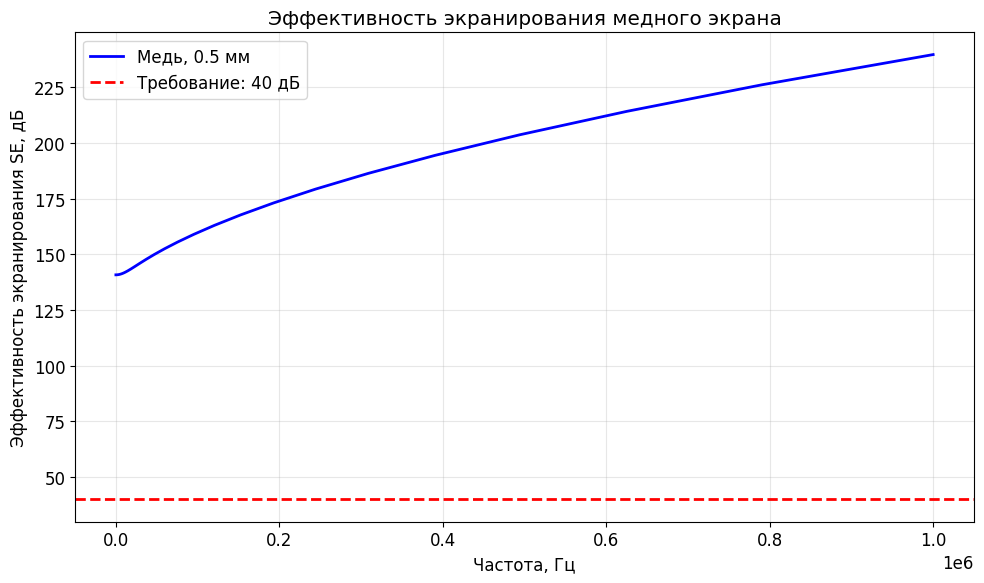

In [133]:
# === ПРИМЕР 2: График SE для одного экрана ===

plt.figure(figsize=(10, 6))
plt.plot(freq_example, se_copper, 'b-', linewidth=2, label='Медь, 0.5 мм')

# Линия ГОСТа (пороговое значение)
gost_level = 40  # дБ — минимальное требуемое SE
plt.axhline(y=gost_level, color='r', linestyle='--', linewidth=2, label=f'Требование: {gost_level} дБ')

plt.xlabel('Частота, Гц')
plt.ylabel('Эффективность экранирования SE, дБ')
plt.title('Эффективность экранирования медного экрана')
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

### 4.3. Пример: создание DataFrame из результатов и работа с ключами

**⚠️ ВНИМАНИЕ: Ключи при создании и ключи при обращении должны совпадать ТОЧНО!**

In [134]:
# === ПРИМЕР 3: Правильная работа с ключами Pandas ===

# Создаём DataFrame — запоминаем ТОЧНЫЕ имена ключей!
df_example = pd.DataFrame({
    'Название': ['Медь'],          # ← Запомните: именно 'Название'
    'sigma_См_м': [5.8e7],         # ← Запомните: именно 'sigma_См_м'
    'толщина_мм': [0.5],           # ← Запомните: именно 'толщина_мм'
    'SE_min_дБ': [se_copper.min()],  # ← Запомните: именно 'SE_min_дБ'
    'SE_max_дБ': [se_copper.max()]   # ← Запомните: именно 'SE_max_дБ'
})

print("=== Столбцы DataFrame ===")
print(df_example.columns.tolist())  # ВСЕГДА проверяйте ключи!

print("\n=== Правильное обращение ===")
print(f"Название: {df_example['Название'].values[0]}")  # ✅
print(f"SE min:   {df_example['SE_min_дБ'].values[0]:.1f} дБ")  # ✅

print("\n=== DataFrame ===")
print(df_example.to_string(index=False))

=== Столбцы DataFrame ===
['Название', 'sigma_См_м', 'толщина_мм', 'SE_min_дБ', 'SE_max_дБ']

=== Правильное обращение ===
Название: Медь
SE min:   140.8 дБ

=== DataFrame ===
Название  sigma_См_м  толщина_мм  SE_min_дБ  SE_max_дБ
    Медь  58000000.0         0.5 140.768566 239.573934


### 4.4. Пример: булевы маски в NumPy

In [135]:
# === ПРИМЕР 4: Булевы маски ===

# Проверяем, на каких частотах SE выше порога
gost_level = 40  # дБ

# Создаём булеву маску
mask_pass = se_copper >= gost_level  # True — экран прошёл, False — не прошёл

print(f"Тип маски: {type(mask_pass)}")
print(f"Форма маски: {mask_pass.shape}")
print(f"Первые 10 значений маски: {mask_pass[:10]}")
print()

# Подсчёт с помощью маски
n_total = len(se_copper)
n_pass = np.sum(mask_pass)           # True считается как 1
n_fail = np.sum(~mask_pass)          # ~ инвертирует маску (True↔False)

print(f"Всего точек: {n_total}")
print(f"SE ≥ {gost_level} дБ: {n_pass} точек")
print(f"SE < {gost_level} дБ: {n_fail} точек")

# Использование маски для извлечения значений
freq_fail = freq_example[~mask_pass]  # Частоты, где экран НЕ проходит
print(f"\nЧастоты, где экран НЕ проходит ГОСТ (первые 5):")
print(f"  {freq_fail[:5]}")

Тип маски: <class 'numpy.ndarray'>
Форма маски: (50,)
Первые 10 значений маски: [ True  True  True  True  True  True  True  True  True  True]

Всего точек: 50
SE ≥ 40 дБ: 50 точек
SE < 40 дБ: 0 точек

Частоты, где экран НЕ проходит ГОСТ (первые 5):
  []


### 4.5. Пример: столбчатая диаграмма

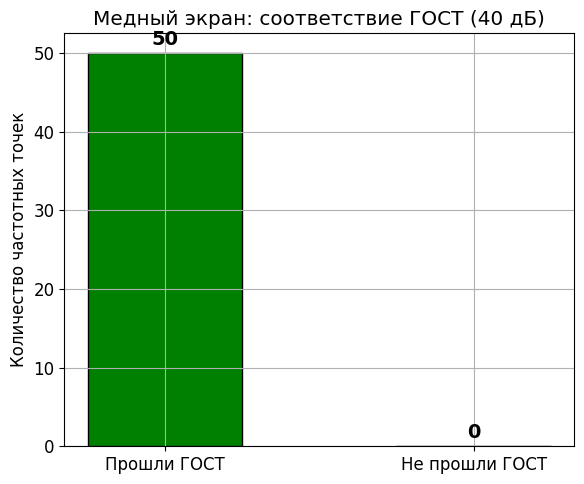

In [136]:
# === ПРИМЕР 5: Столбчатая диаграмма ===

categories = ['Прошли ГОСТ', 'Не прошли ГОСТ']
values = [int(n_pass), int(n_fail)]
colors = ['green', 'red']

plt.figure(figsize=(6, 5))
bars = plt.bar(categories, values, color=colors, edgecolor='black', width=0.5)

# Подписи значений над столбцами
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             str(val), ha='center', va='bottom', fontsize=14, fontweight='bold')

plt.ylabel('Количество частотных точек')
plt.title(f'Медный экран: соответствие ГОСТ ({gost_level} дБ)')
plt.tight_layout()
plt.show()

---
## 5. Справочные данные по металлам

В заданиях используйте следующие параметры металлов:

| Металл | $\mu_r$ | $\varepsilon_r$ | $\sigma$, См/м | Тип |
|--------|---------|-----------------|----------------|-----|
| Медь (Cu) | 1.0 | 1.0 | 5.8×10⁷ | 1 |
| Алюминий (Al) | 1.0 | 1.0 | 3.5×10⁷ | 1 |
| Сталь (Steel) | 100.0 | 1.0 | 1.0×10⁷ | 1 |
| Никель (Ni) | 100.0 | 1.0 | 1.45×10⁷ | 1 |
| Олово (Sn) | 1.0 | 1.0 | 8.7×10⁶ | 1 |
| Цинк (Zn) | 1.0 | 1.0 | 1.69×10⁷ | 1 |
| Латунь (Brass) | 1.0 | 1.0 | 1.5×10⁷ | 1 |
| Пермаллой (Permalloy) | 8000.0 | 1.0 | 1.0×10⁶ | 1 |
| Нерж. сталь (Stainless) | 1.02 | 1.0 | 1.4×10⁶ | 1 |
| Свинец (Pb) | 1.0 | 1.0 | 4.8×10⁶ | 1 |

---
## 📝 Задание 1: Формирование массивов экранов (NumPy)

### Условие

1. Создайте массив частот `freq` от 10 кГц до 1 ГГц, **100 точек**, логарифмическая шкала.
2. Создайте массивы `table` для **6 различных однослойных металлических экранов** толщиной **1 мм** каждый:
   - Медь, Алюминий, Сталь, Никель, Олово, Латунь
3. Рассчитайте SE для каждого экрана с помощью функции `calc_shield_se()`.
4. Сохраните все результаты SE в **один 2D массив** `se_all` размером `(6, 100)`.
5. С помощью **булевой маски** определите:
   - На скольких частотах КАЖДЫЙ экран обеспечивает SE ≥ 50 дБ
   - Какой экран имеет **максимальный** средний SE

In [137]:
# === ЗАДАНИЕ 1: Формирование массивов экранов ===

# --- Шаг 1: Массив частот ---
# создайте массив частот от 10 кГц (1e4) до 1 ГГц (1e9), 100 точек
freq = np.linspace(1e3, 1e7, 100)

print(f"Массив частот: {len(freq)} точек")
print(f"  от {freq[0]:.0f} Гц до {freq[-1]:.2e} Гц")

# --- Шаг 2: Параметры экранов ---
# Толщина для всех — 1 мм = 0.001 м
t = 0.001  # м

# создайте список названий экранов
names = np.array(['медь','алюминий','сталь',"никель", "олово", "латунь"])

# создайте 6 массивов table для каждого металла
# Формат: np.array([mu_r, eps_r, sigma, толщина, тип])
table_cu = np.array([1.0,	1.0,	5.8e7, t,	1])
table_al = np.array([1.0,	1.0,	3.5e7,t,	1])
table_steel = np.array([100.0,	1.0,	1.0e7,t,	1])
table_ni = np.array([100.0,	1.0,	1.45e7,	t,1])
table_sn = np.array([1.0,	1.0,	8.7e6,t,	1])
table_brass = np.array([1.0,	1.0,	1.5e7,	t,1])

# ✏️  соберите все таблицы в список
tables = np.array( [table_cu, table_al, table_steel, table_ni, table_sn, table_brass])

# --- Шаг 3: Расчёт SE для каждого экрана ---
# создайте пустой 2D массив se_all размером (6, 100) и заполните его в цикле
se_all =np.zeros((6,100))
for i, j in enumerate(tables):
  se_all[i,:]= calc_shield_se(freq, j)


print(f"\nРазмер массива se_all: {se_all.shape}")

# --- Шаг 4: Булевы маски ---
gost_level_1 = 50  # дБ

print(f"\n=== Анализ: SE ≥ {gost_level_1} дБ ===")

for idx, name in enumerate(names):
    # создайте булеву маску для проверки SE ≥ gost_level_1
    mask = se_all[idx,:] >= gost_level_1
    # подсчитайте количество True в маске
    n_pass = np.sum(mask)
    print(f"  {name:12s}: {n_pass:3d} из {len(freq)} частот прошли порог")

# --- Шаг 5: Лучший экран по среднему SE ---
# вычислите средний SE для каждого экрана (по оси 1) и найдите индекс максимума
se_mean = np.mean(se_all,1)
best_idx = np.argmax(se_mean)

print(f"\n=== Средний SE по всем частотам ===")

Массив частот: 100 точек
  от 1000 Гц до 1.00e+07 Гц

Размер массива se_all: (6, 100)

=== Анализ: SE ≥ 50 дБ ===
  медь        : 100 из 100 частот прошли порог
  алюминий    : 100 из 100 частот прошли порог
  сталь       : 100 из 100 частот прошли порог
  никель      : 100 из 100 частот прошли порог
  олово       : 100 из 100 частот прошли порог
  латунь      : 100 из 100 частот прошли порог

=== Средний SE по всем частотам ===


---
## 📝 Задание 2: Варьирование толщины экрана (NumPy + Matplotlib)

### Условие

1. Выберите **один металл — медь**.
2. Создайте массив толщин: **0.1, 0.3, 0.5, 1.0, 2.0, 5.0 мм**.
3. Рассчитайте SE для каждой толщины.
4. Постройте **один график** с кривыми SE(f) для всех толщин.
5. Добавьте горизонтальную линию ГОСТ = 60 дБ.
6. С помощью **векторизации** (без циклов по элементам!) найдите для каждой толщины
   **минимальное SE** и **процент частот**, где SE ≥ 60 дБ.

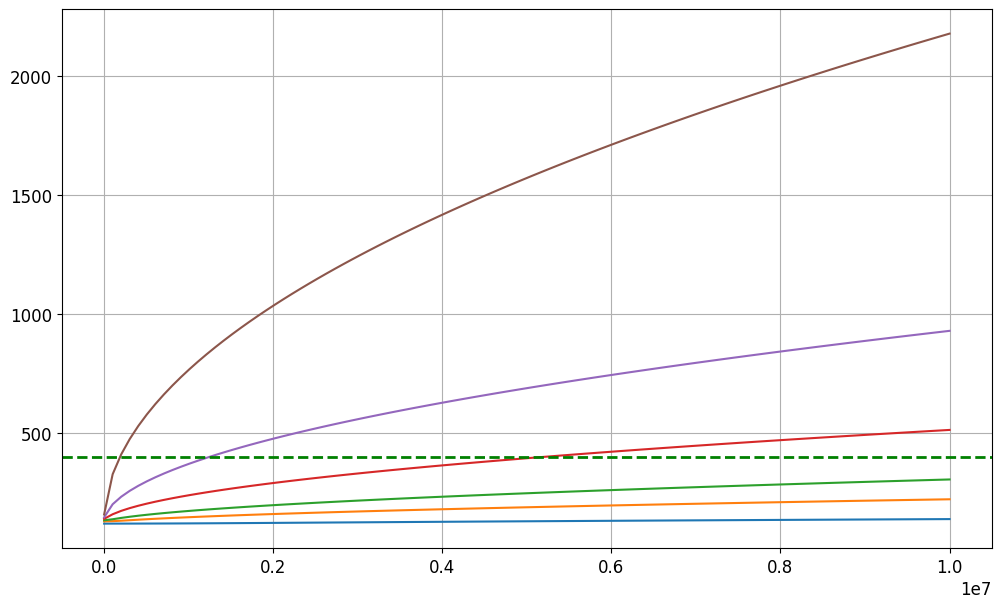


=== Анализ по толщинам (ГОСТ = 400 дБ) ===
[ 0.  0.  0. 48. 87. 98.]


In [138]:
# === ЗАДАНИЕ 2: Варьирование толщины ===

# создайте массив толщин в мм
thicknesses_mm = np.array([ 0.1, 0.3, 0.5, 1.0, 2.0, 5.0])
# переведите в метры
thicknesses_m = thicknesses_mm*1e-3

# Параметры меди (без толщины и типа — добавим в цикле)
sigma_cu = 5.8e7
mu_r_cu = 1.0
eps_r_cu = 1.0

# Массив для результатов
se_thickness = np.ones((6,100))

# ✏️ заполните se_thickness — для каждой толщины создайте table и вызовите calc_shield_se
for idx, j in enumerate(thicknesses_m):
  se_thickness[idx,:]= calc_shield_se(freq, np.array([mu_r_cu, eps_r_cu, sigma_cu, j, 1]))

# --- График ---
plt.figure(figsize=(12, 7))

# постройте кривые SE(f) для каждой толщины с подписями в легенде
for i in range (len(thicknesses_m)):
  plt.plot(freq, se_thickness[i,:], linewidth=1.5, label=str(thicknesses_mm[i]))


# добавьте горизонтальную линию ГОСТ = 60 дБ
gost_level_2 = 400
plt.axhline(y=gost_level_2, color='g', linestyle='--', linewidth=2, label=f'Требование: {gost_level} дБ')
plt.show()
# --- Анализ с помощью векторизации (БЕЗ циклов по элементам!) ---
print(f"\n=== Анализ по толщинам (ГОСТ = {gost_level_2} дБ) ===")

# ✏️ найдите минимальное SE для каждой толщины по оси 1
se_min_per_thickness = np.min(se_thickness,1)

# посчитайте процент частот, где SE ≥ ГОСТ для каждой толщины
# Подсказка: создайте булеву маску для всей матрицы, затем np.sum по оси 1, делите на len(freq)*100
mask_gost = se_thickness >= gost_level_2
pct_pass = (np.sum(mask_gost,1)/len(freq))*100
print(pct_pass)




---
## 📝 Задание 3: Сводная таблица в Pandas и анализ

### Условие

1. Создайте DataFrame со **всеми комбинациями** «металл × толщина»:
   - 6 металлов × 4 толщины (0.3, 0.5, 1.0, 2.0 мм) = **24 варианта**
2. Для каждого варианта рассчитайте и запишите:
   - `SE_min` — минимальный SE по всем частотам
   - `SE_max` — максимальный SE
   - `SE_mean` — средний SE
   - `ГОСТ` — пометка «Да» или «Нет» (SE_min ≥ 50 дБ)
3. Отобразите **5 лучших экранов** по `SE_min`.
4. Отобразите **все экраны, НЕ прошедшие ГОСТ**.
5. Постройте **столбчатую диаграмму**: количество прошедших/не прошедших ГОСТ.

**⚠️ ВАЖНО: Внимательно следите за ключами DataFrame! Используйте `print(df.columns.tolist())` для проверки!**

In [139]:
# === ЗАДАНИЕ 3: Сводная таблица ===

# Параметры
metals_info = {
    'Медь':     {'mu_r': 1.0,    'eps_r': 1.0, 'sigma': 5.8e7},
    'Алюминий': {'mu_r': 1.0,    'eps_r': 1.0, 'sigma': 3.5e7},
    'Сталь':    {'mu_r': 100.0,  'eps_r': 1.0, 'sigma': 1.0e7},
    'Никель':   {'mu_r': 100.0,  'eps_r': 1.0, 'sigma': 1.45e7},
    'Олово':    {'mu_r': 1.0,    'eps_r': 1.0, 'sigma': 8.7e6},
    'Латунь':   {'mu_r': 1.0,    'eps_r': 1.0, 'sigma': 1.5e7},
}

# задайте массив толщин (мм) и порог ГОСТ
thicknesses_task3 = np.array([0.3, 0.5, 1.0, 2.0])
gost_level_3 = 50  # дБ

name_=[]
char_=[]
thick_=[]
se_min_=[]
se_max_=[]
gost_=[]
results=pd.DataFrame({
    'Металл': [],
    'характеристики':[],
    'Толщина_мм': [],
    'SE_min_дБ': [],
    'SE_max_дБ': [],
    'ГОСТ':[]
})
for idx, i in enumerate(names):
  for j in thicknesses_task3:
    mm=tables[idx]
    se=calc_shield_se(freq, mm)
    name_.append(i)
    char_.append(tables[idx][2])
    thick_.append(j)
    se_min_.append(se.min())
    se_max_.append(se.max())
    if se.min() >= gost_level_3:
      gost_.append('ДА')
    else:
      gost_.append('НЕТ')
results['Металл']=name_
results['характеристики']=char_
results['Толщина_мм']=thick_
results['SE_min_дБ']=se_min_
results['SE_max_дБ']=se_max_
results['ГОСТ']=gost_

# --- Вывод полной таблицы ---
print("=== Полная таблица результатов ===")
print(results)


=== Полная таблица результатов ===
      Металл  характеристики  Толщина_мм   SE_min_дБ    SE_max_дБ ГОСТ
0       медь      58000000.0         0.3  140.778675   513.771055   ДА
1       медь      58000000.0         0.5  140.778675   513.771055   ДА
2       медь      58000000.0         1.0  140.778675   513.771055   ДА
3       медь      58000000.0         2.0  140.778675   513.771055   ДА
4   алюминий      35000000.0         0.3  136.385050   418.816611   ДА
5   алюминий      35000000.0         0.5  136.385050   418.816611   ДА
6   алюминий      35000000.0         1.0  136.385050   418.816611   ДА
7   алюминий      35000000.0         2.0  136.385050   418.816611   ДА
8      сталь      10000000.0         0.3  127.873732  1796.321169   ДА
9      сталь      10000000.0         0.5  127.873732  1796.321169   ДА
10     сталь      10000000.0         1.0  127.873732  1796.321169   ДА
11     сталь      10000000.0         2.0  127.873732  1796.321169   ДА
12    никель      14500000.0         0.3  

### Задание 3.2: Фильтрация и сортировка DataFrame

In [140]:
# === ТОП-5 лучших экранов по SE_min ===

# отсортируйте df по столбцу 'SE_min_дБ' по убыванию и возьмите первые 5 строк
top5 = results['SE_min_дБ'].sort_values(ascending=False).head(5)

print("=== ТОП-5 лучших экранов (по минимальному SE) ===")
# print(top5[['Металл', 'Толщина_мм', 'SE_min_дБ', 'SE_mean_дБ', 'ГОСТ']].to_string(index=False))

# === Экраны, НЕ прошедшие ГОСТ ===
df_fail=results[results['ГОСТ']=="НЕТ"]
print(df_fail[['Металл', 'Толщина_мм', 'SE_min_дБ']].to_string(index=False), "\n\n")
print(df_fail,'\n\n')
# === Экраны, прошедшие ГОСТ ===
df_pass=results[results['ГОСТ']=="ДА"]
# отфильтруйте строки, где столбец 'ГОСТ' равен 'Да'
print(df_pass[['Металл', 'Толщина_мм', 'SE_min_дБ']].to_string(index=False),'\n\n')
print(df_pass)
print(df_pass[['Металл', 'Толщина_мм', 'SE_min_дБ']].to_string(index=False))

=== ТОП-5 лучших экранов (по минимальному SE) ===
Empty DataFrame
Columns: [Металл, Толщина_мм, SE_min_дБ]
Index: [] 


Empty DataFrame
Columns: [Металл, характеристики, Толщина_мм, SE_min_дБ, SE_max_дБ, ГОСТ]
Index: [] 


  Металл  Толщина_мм  SE_min_дБ
    медь         0.3 140.778675
    медь         0.5 140.778675
    медь         1.0 140.778675
    медь         2.0 140.778675
алюминий         0.3 136.385050
алюминий         0.5 136.385050
алюминий         1.0 136.385050
алюминий         2.0 136.385050
   сталь         0.3 127.873732
   сталь         0.5 127.873732
   сталь         1.0 127.873732
   сталь         2.0 127.873732
  никель         0.3 132.895783
  никель         0.5 132.895783
  никель         1.0 132.895783
  никель         2.0 132.895783
   олово         0.3 124.290622
   олово         0.5 124.290622
   олово         1.0 124.290622
   олово         2.0 124.290622
  латунь         0.3 129.022509
  латунь         0.5 129.022509
  латунь         1.0 129.022509
  латунь 

### Задание 3.3: Столбчатая диаграмма прошедших/не прошедших ГОСТ

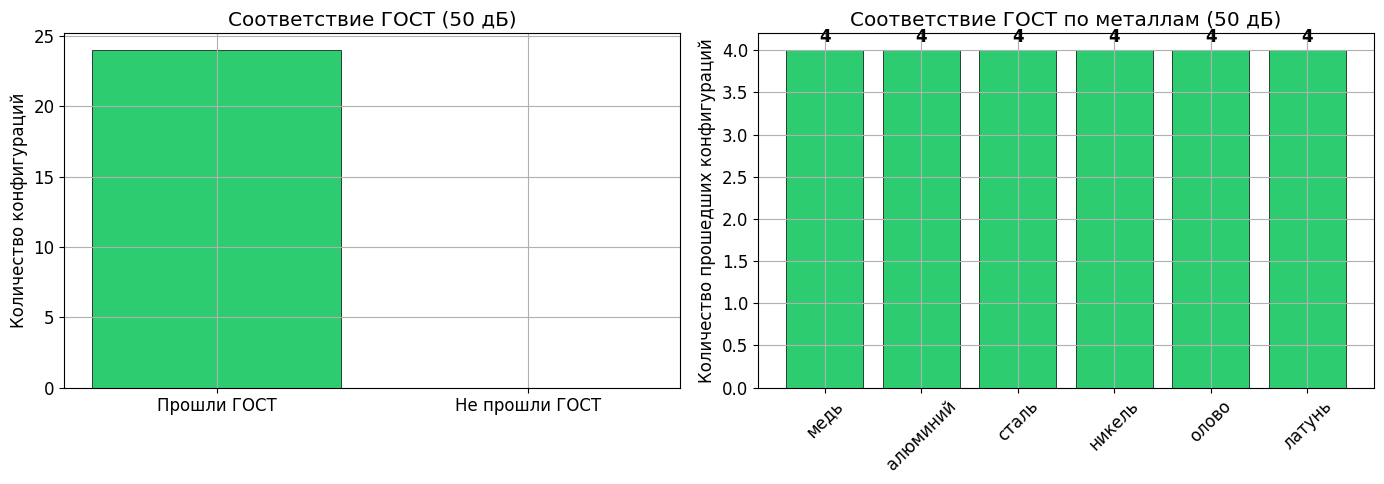

In [141]:

# === Столбчатая диаграмма: ГОСТ ===

# подсчитайте количество 'Да' и 'Нет' в столбце 'ГОСТ'
n_pass_gost =len([i for i in df_pass['ГОСТ'] if i=='ДА'])
n_fail_gost =len([i for i in df_fail['ГОСТ'] if i=='НЕТ'])
#  постройте столбчатую диаграмму с подписями значений
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Левый график: общий результат ГОСТ ---
categories = ['Прошли ГОСТ', 'Не прошли ГОСТ']
values = [n_pass_gost, n_fail_gost]
colors = ['#2ecc71', '#e74c3c']

axes[0].bar(categories, values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_ylabel('Количество конфигураций')
axes[0].set_title(f'Соответствие ГОСТ ({gost_level_3} дБ)')

# --- Правый график: по металлам (сколько толщин прошло ГОСТ для каждого металла) ---
pass_count_by_metal = []

for metal in names:
    n_pass = len(results[(results['Металл'] == metal) & (results['ГОСТ'] == 'ДА')])
    pass_count_by_metal.append(n_pass)
colors_metal = ['#2ecc71' if count > 0 else '#e74c3c' for count in pass_count_by_metal]
axes[1].bar(names, pass_count_by_metal, color=colors_metal, edgecolor='black', linewidth=0.5)
axes[1].set_ylabel('Количество прошедших конфигураций')
axes[1].set_title(f'Соответствие ГОСТ по металлам ({gost_level_3} дБ)')
axes[1].tick_params(axis='x', rotation=45)

# для каждого металла подсчитайте количество прошедших ГОСТ конфигураций
for i, v in enumerate(pass_count_by_metal):
    axes[1].text(i, v + 0.1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 📝 Задание 4: Сравнительные графики (Matplotlib)

### Условие

1. Постройте **один график** с кривыми SE(f) для всех 6 металлов при **одинаковой толщине 1 мм**.
2. На этом же графике — горизонтальная линия ГОСТ.
3. Постройте **горизонтальную столбчатую диаграмму** (`barh`), показывающую средний SE для каждого металла при толщине 1 мм.
4. Пометьте цветом столбцы: зелёный — прошёл ГОСТ, красный — нет.

---
## 🌟 БОНУСНОЕ ЗАДАНИЕ: Индивидуальный вариант

### Как это работает

1. Запустите ячейку ниже — она **случайным образом** выберет вам вариант.
2. Вы получите: **металл**, **толщину**, **порог ГОСТ** и **набор задач**.
3. Выполните все задачи **самостоятельно** в новых ячейках ниже.

### Таблица вариантов

| Вариант | Металл 1 | Металл 2 | Толщина, мм | ГОСТ, дБ | Доп. задача |
|---------|----------|----------|-------------|----------|-------------|
| 1 | Медь | Сталь | 0.3 | 40 | Сравнить на одном графике |
| 2 | Алюминий | Никель | 0.5 | 45 | Найти частоту пересечения кривых |
| 3 | Олово | Латунь | 1.0 | 50 | Столбчатая диаграмма SE_mean |
| 4 | Сталь | Медь | 2.0 | 55 | Тепловая карта двух металлов × 3 толщины |
| 5 | Никель | Цинк | 0.5 | 60 | Круговая диаграмма категорий |
| 6 | Латунь | Алюминий | 1.0 | 45 | Найти макс. SE и частоту, на которой он достигается |
| 7 | Медь | Пермаллой | 0.1 | 30 | Сравнить магнитный и немагнитный материал |
| 8 | Нерж. сталь | Свинец | 0.5 | 35 | barh-диаграмма для 4-х толщин |
| 9 | Цинк | Сталь | 1.5 | 50 | Построить SE для 5 толщин, DataFrame с результатами |
| 10 | Пермаллой | Олово | 0.3 | 55 | Сравнить экстремально магнитный и обычный металл |

In [142]:
# === БОНУСНОЕ ЗАДАНИЕ: Генерация индивидуального варианта ===

variants = [
    {
        'номер': 1,
        'металл_1': 'Медь',       'params_1': {'mu_r': 1.0,    'eps_r': 1.0, 'sigma': 5.8e7},
        'металл_2': 'Сталь',      'params_2': {'mu_r': 100.0,  'eps_r': 1.0, 'sigma': 1.0e7},
        'толщина_мм': 0.3, 'ГОСТ_дБ': 40,
        'задача': 'Постройте кривые SE(f) обоих металлов на одном графике + линия ГОСТ.\n'
                  'Создайте DataFrame с результатами. Определите, какой металл лучше.'
    },
    {
        'номер': 2,
        'металл_1': 'Алюминий',   'params_1': {'mu_r': 1.0,    'eps_r': 1.0, 'sigma': 3.5e7},
        'металл_2': 'Никель',     'params_2': {'mu_r': 100.0,  'eps_r': 1.0, 'sigma': 1.45e7},
        'толщина_мм': 0.5, 'ГОСТ_дБ': 45,
        'задача': 'Постройте SE(f) для обоих металлов. Найдите частоту, на которой кривые пересекаются.\n'
                  'Подсказка: найдите индекс минимальной разности |SE1 - SE2|.\n'
                  'Создайте DataFrame, столбчатую диаграмму SE_mean.'
    },
    {
        'номер': 3,
        'металл_1': 'Олово',      'params_1': {'mu_r': 1.0,    'eps_r': 1.0, 'sigma': 8.7e6},
        'металл_2': 'Латунь',     'params_2': {'mu_r': 1.0,    'eps_r': 1.0, 'sigma': 1.5e7},
        'толщина_мм': 1.0, 'ГОСТ_дБ': 50,
        'задача': 'Рассчитайте SE для обоих металлов при 3 толщинах (0.5, 1.0, 2.0 мм).\n'
                  'Запишите всё в DataFrame (6 строк). Постройте столбчатую диаграмму SE_mean.\n'
                  'Определите, сколько конфигураций прошли ГОСТ.'
    },
    {
        'номер': 4,
        'металл_1': 'Сталь',      'params_1': {'mu_r': 100.0,  'eps_r': 1.0, 'sigma': 1.0e7},
        'металл_2': 'Медь',       'params_2': {'mu_r': 1.0,    'eps_r': 1.0, 'sigma': 5.8e7},
        'толщина_мм': 2.0, 'ГОСТ_дБ': 55,
        'задача': 'Рассчитайте SE для обоих металлов при 3 толщинах (0.5, 1.0, 2.0 мм).\n'
                  'Постройте тепловую карту (2 металла × 3 толщины).\n'
                  'Создайте DataFrame и выведите ТОП-3 конфигурации.'
    },
    {
        'номер': 5,
        'металл_1': 'Никель',     'params_1': {'mu_r': 100.0,  'eps_r': 1.0, 'sigma': 1.45e7},
        'металл_2': 'Цинк',      'params_2': {'mu_r': 1.0,    'eps_r': 1.0, 'sigma': 1.69e7},
        'толщина_мм': 0.5, 'ГОСТ_дБ': 60,
        'задача': 'Постройте SE(f) для обоих металлов + ГОСТ.\n'
                  'Классифицируйте по категориям (Отлично/Хорошо/Недостаточно).\n'
                  'Постройте круговую диаграмму категорий для 4 толщин × 2 металла.'
    },
    {
        'номер': 6,
        'металл_1': 'Латунь',     'params_1': {'mu_r': 1.0,    'eps_r': 1.0, 'sigma': 1.5e7},
        'металл_2': 'Алюминий',   'params_2': {'mu_r': 1.0,    'eps_r': 1.0, 'sigma': 3.5e7},
        'толщина_мм': 1.0, 'ГОСТ_дБ': 45,
        'задача': 'Рассчитайте SE для обоих металлов. Найдите максимальный SE и частоту,\n'
                  'на которой он достигается (используйте np.argmax).\n'
                  'Постройте график и отметьте точку максимума маркером.'
    },
    {
        'номер': 7,
        'металл_1': 'Медь',       'params_1': {'mu_r': 1.0,    'eps_r': 1.0, 'sigma': 5.8e7},
        'металл_2': 'Пермаллой',  'params_2': {'mu_r': 8000.0, 'eps_r': 1.0, 'sigma': 1.0e6},
        'толщина_мм': 0.1, 'ГОСТ_дБ': 30,
        'задача': 'Сравните магнитный (Пермаллой, μᵣ=8000) и немагнитный (Медь, μᵣ=1) материалы.\n'
                  'Постройте SE(f) на одном графике. В каком диапазоне частот какой лучше?\n'
                  'Используйте булеву маску для определения диапазонов.'
    },
    {
        'номер': 8,
        'металл_1': 'Нерж. сталь','params_1': {'mu_r': 1.02,   'eps_r': 1.0, 'sigma': 1.4e6},
        'металл_2': 'Свинец',     'params_2': {'mu_r': 1.0,    'eps_r': 1.0, 'sigma': 4.8e6},
        'толщина_мм': 0.5, 'ГОСТ_дБ': 35,
        'задача': 'Рассчитайте SE для обоих металлов при 4 толщинах (0.3, 0.5, 1.0, 2.0 мм).\n'
                  'Постройте горизонтальную столбчатую диаграмму (barh) SE_min для всех 8 конфигураций.\n'
                  'Пометьте цветом: зелёный — ГОСТ пройден, красный — нет.'
    },
    {
        'номер': 9,
        'металл_1': 'Цинк',       'params_1': {'mu_r': 1.0,    'eps_r': 1.0, 'sigma': 1.69e7},
        'металл_2': 'Сталь',      'params_2': {'mu_r': 100.0,  'eps_r': 1.0, 'sigma': 1.0e7},
        'толщина_мм': 1.5, 'ГОСТ_дБ': 50,
        'задача': 'Рассчитайте SE для обоих металлов при 5 толщинах (0.1, 0.3, 0.5, 1.0, 1.5 мм).\n'
                  'Постройте SE(f) для всех 10 конфигураций на одном графике (используйте разные стили линий).\n'
                  'Создайте DataFrame с полным отчётом.'
    },
    {
        'номер': 10,
        'металл_1': 'Пермаллой',  'params_1': {'mu_r': 8000.0, 'eps_r': 1.0, 'sigma': 1.0e6},
        'металл_2': 'Олово',      'params_2': {'mu_r': 1.0,    'eps_r': 1.0, 'sigma': 8.7e6},
        'толщина_мм': 0.3, 'ГОСТ_дБ': 55,
        'задача': 'Сравните экстремально магнитный (Пермаллой) и обычный (Олово) металл.\n'
                  'Рассчитайте SE при 3 толщинах. Постройте субплоты: слева — графики SE(f),\n'
                  'справа — столбчатая диаграмма SE_min. Выведите итоговый DataFrame.'
    },
]

# --- Случайный выбор варианта ---
variant = random.choice(variants)

print("=" * 70)
print(f"  🎲 ВАШ ИНДИВИДУАЛЬНЫЙ ВАРИАНТ: №{variant['номер']}")
print("=" * 70)
print(f"\n  Металл 1: {variant['металл_1']}")
print(f"    μᵣ = {variant['params_1']['mu_r']}, "
      f"εᵣ = {variant['params_1']['eps_r']}, "
      f"σ = {variant['params_1']['sigma']:.2e} См/м")
print(f"\n  Металл 2: {variant['металл_2']}")
print(f"    μᵣ = {variant['params_2']['mu_r']}, "
      f"εᵣ = {variant['params_2']['eps_r']}, "
      f"σ = {variant['params_2']['sigma']:.2e} См/м")
print(f"\n  Толщина: {variant['толщина_мм']} мм")
print(f"  Порог ГОСТ: {variant['ГОСТ_дБ']} дБ")
print(f"\n  📋 ЗАДАНИЕ:")
print(f"  {variant['задача']}")
print("\n" + "=" * 70)
print("  Выполните задание в ячейках ниже ↓")
print("=" * 70)

  🎲 ВАШ ИНДИВИДУАЛЬНЫЙ ВАРИАНТ: №10

  Металл 1: Пермаллой
    μᵣ = 8000.0, εᵣ = 1.0, σ = 1.00e+06 См/м

  Металл 2: Олово
    μᵣ = 1.0, εᵣ = 1.0, σ = 8.70e+06 См/м

  Толщина: 0.3 мм
  Порог ГОСТ: 55 дБ

  📋 ЗАДАНИЕ:
  Сравните экстремально магнитный (Пермаллой) и обычный (Олово) металл.
Рассчитайте SE при 3 толщинах. Постройте субплоты: слева — графики SE(f),
справа — столбчатая диаграмма SE_min. Выведите итоговый DataFrame.

  Выполните задание в ячейках ниже ↓


### Выполнение бонусного задания

Используйте ячейки ниже для выполнения индивидуального варианта.
Вам нужно:
1. Создать массивы `table` для ваших металлов
2. Рассчитать SE с помощью `calc_shield_se()`
3. Создать DataFrame с результатами (СЛЕДИТЕ ЗА КЛЮЧАМИ!)
4. Построить требуемые графики
5. Сделать выводы

In [143]:
# === Ваш код для бонусного задания ===
# Подсказка: скопируйте параметры металлов из вашего варианта выше
print("=======> Вариант 8 <=======")
# ======================================================================
#   🎲 ВАШ ИНДИВИДУАЛЬНЫЙ ВАРИАНТ: №8
# ======================================================================

#   Металл 1: Нерж. сталь
#     μᵣ = 1.02, εᵣ = 1.0, σ = 1.40e+06 См/м

#   Металл 2: Свинец
#     μᵣ = 1.0, εᵣ = 1.0, σ = 4.80e+06 См/м

#   Толщина: 0.5 мм
#   Порог ГОСТ: 35 дБ

#   📋 ЗАДАНИЕ:
#   Рассчитайте SE для обоих металлов при 4 толщинах (0.3, 0.5, 1.0, 2.0 мм).
# Постройте горизонтальную столбчатую диаграмму (barh) SE_min для всех 8 конфигураций.
# Пометьте цветом: зелёный — ГОСТ пройден, красный — нет.

# выполните индивидуальное задание полностью

# Шаг 1: Создайте массив частот

freq_individ = np.logspace(1, 6, 50)

# Шаг 2: Создайте table для каждого металла

# table_1 = np.array([])
# table_2 = np.array([...])

# Шаг 3: Рассчитайте SE
# se_1 = calc_shield_se(freq_bonus, table_1)
# se_2 = calc_shield_se(freq_bonus, table_2)

# Шаг 4: Постройте графики

# Шаг 5: Создайте DataFrame

# Шаг 6: Сделайте выводы

print("Здесь будет ваше решение бонусного задания!")

=======> Вариант 8 <=======
Здесь будет ваше решение бонусного задания!
